# Questão 6 - Equação Diferencial Parcial Elíptica (Algoritmo 12.1)

Utilize o Algoritmo 12.1 para determinar uma solução aproximada da equação diferencial parcial elíptica:

$$\frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} = 8, \quad 0 < x < 1, \quad 0 < y < 2$$

**Condições de contorno:**

$$u(x,0) = x^2, \quad u(x,2) = (x-2)^2, \quad 0 \leq x \leq 1$$

$$u(0,y) = y^2, \quad u(1,y) = (y-1)^2, \quad 0 \leq y \leq 2$$

Use $h = k = \frac{1}{2}$ e compare os resultados com a solução real:

$$u(x,y) = (x - y)^2$$

QUESTÃO 6 - Equação Elíptica
Convergência alcançada em 11 iterações

Resultados (pontos internos):
--------------------------------------------------------------------------------
x		y		Aproximado		Real (x-y)^2		Erro
--------------------------------------------------------------------------------
0.50		0.50		-0.3571428574		0.0000000000		0.3571428574
0.50		1.00		-0.1785714287		0.2500000000		0.4285714287
0.50		1.50		0.6428571428		1.0000000000		0.3571428572
VERIFICAÇÃO DA SOLUÇÃO REAL
u_xx + u_yy = 4
O lado direito da EDP é f(x,y) = 8

ATENÇÃO: A solução real u(x,y) = (x-y)^2 NÃO satisfaz a EDP,
pois u_xx + u_yy = 4, mas a equação pede u_xx + u_yy = 8.
O enunciado pode ter um erro (deveria ser = 4) ou a solução real está incorreta.


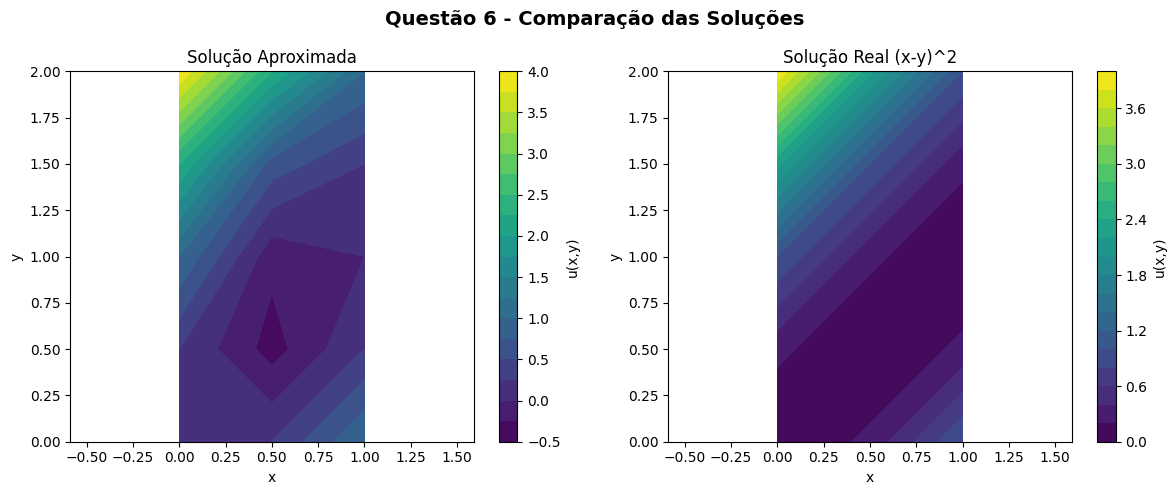

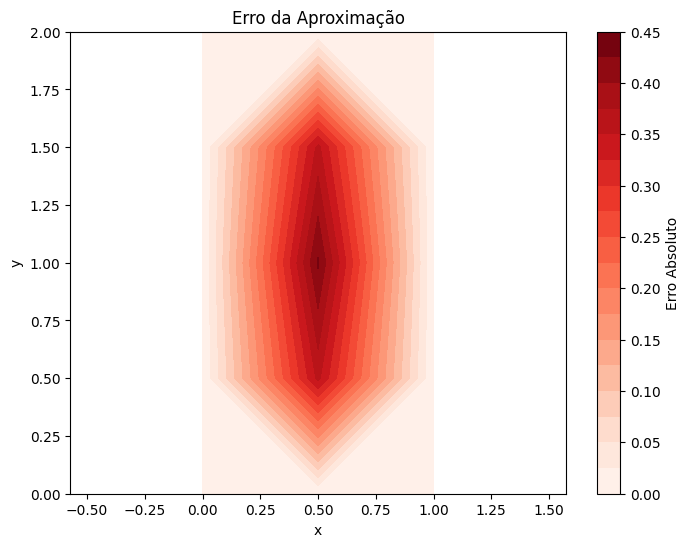

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def poisson_solver(f, x0, xf, y0, yf, h, k, boundary_func, max_iter=10000, tol=1e-8):
    """
    Resolve a equação de Poisson: u_xx + u_yy = f(x,y)
    usando o método de diferenças finitas (Algoritmo 12.1) - Gauss-Seidel
    """
    nx = int((xf - x0) / h) + 1
    ny = int((yf - y0) / k) + 1
    
    x = np.linspace(x0, xf, nx)
    y = np.linspace(y0, yf, ny)
    
    u = np.zeros((nx, ny))
    
    # Condições de contorno
    for i in range(nx):
        for j in range(ny):
            u[i, j] = boundary_func(x[i], y[j], x0, xf, y0, yf)
    
    h2 = h**2
    k2 = k**2
    coef = 2*(1/h2 + 1/k2)
    
    for it in range(max_iter):
        u_old = u.copy()
        for i in range(1, nx-1):
            for j in range(1, ny-1):
                u[i, j] = ((u[i-1, j] + u[i+1, j])/h2 + (u[i, j-1] + u[i, j+1])/k2 - f(x[i], y[j])) / coef
        
        if np.max(np.abs(u - u_old)) < tol:
            print(f"Convergência alcançada em {it+1} iterações")
            break
    
    return x, y, u

# QUESTÃO 6

print("QUESTÃO 6 - Equação Elíptica")

# Função do lado direito
def f6(x, y):
    return 8  # Conforme o enunciado

# Condições de contorno
def boundary6(x, y, x0, xf, y0, yf):
    if y == y0:      # u(x,0) = x^2
        return x**2
    elif y == yf:    # u(x,2) = (x-2)^2
        return (x - 2)**2
    elif x == x0:    # u(0,y) = y^2
        return y**2
    elif x == xf:    # u(1,y) = (y-1)^2
        return (y - 1)**2
    else:
        return 0

# Solução real (conforme enunciado)
def real6(x, y):
    return (x - y)**2

# Parâmetros
x0, xf, y0, yf = 0, 1, 0, 2
h, k = 0.5, 0.5

# Resolver
x, y, u = poisson_solver(f6, x0, xf, y0, yf, h, k, boundary6)

# Imprimir resultados
print("\nResultados (pontos internos):")
print("-"*80)
print("x\t\ty\t\tAproximado\t\tReal (x-y)^2\t\tErro")
print("-"*80)

for i in range(len(x)):
    for j in range(len(y)):
        # Pula contornos
        if i == 0 or i == len(x)-1 or j == 0 or j == len(y)-1:
            continue
        real_val = real6(x[i], y[j])
        erro = abs(u[i, j] - real_val)
        print(f"{x[i]:.2f}\t\t{y[j]:.2f}\t\t{u[i, j]:.10f}\t\t{real_val:.10f}\t\t{erro:.10f}")

# Verificar se a solução real satisfaz a EDP

print("VERIFICAÇÃO DA SOLUÇÃO REAL")

def real6_xx(x, y):
    return 2  # segunda derivada em x de (x-y)^2

def real6_yy(x, y):
    return 2  # segunda derivada em y de (x-y)^2

print(f"u_xx + u_yy = {real6_xx(0.5, 1) + real6_yy(0.5, 1)}")
print(f"O lado direito da EDP é f(x,y) = 8")
print("\nATENÇÃO: A solução real u(x,y) = (x-y)^2 NÃO satisfaz a EDP,")
print("pois u_xx + u_yy = 4, mas a equação pede u_xx + u_yy = 8.")
print("O enunciado pode ter um erro (deveria ser = 4) ou a solução real está incorreta.")

# Gráfico de contorno
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
X, Y = np.meshgrid(x, y)
plt.contourf(X, Y, u.T, levels=20, cmap='viridis')
plt.colorbar(label='u(x,y)')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Solução Aproximada')
plt.axis('equal')

plt.subplot(1, 2, 2)
u_real = np.zeros((len(x), len(y)))
for i in range(len(x)):
    for j in range(len(y)):
        u_real[i, j] = real6(x[i], y[j])
plt.contourf(X, Y, u_real.T, levels=20, cmap='viridis')
plt.colorbar(label='u(x,y)')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Solução Real (x-y)^2')
plt.axis('equal')

plt.suptitle('Questão 6 - Comparação das Soluções', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Gráfico de erros
plt.figure(figsize=(8, 6))
erro = np.abs(u.T - real6(X, Y))
plt.contourf(X, Y, erro, levels=20, cmap='Reds')
plt.colorbar(label='Erro Absoluto')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Erro da Aproximação')
plt.axis('equal')
plt.show()